# Self-generated probes on gemma-4-31b-it (Q1.H2.E5 pilot)

The last live methodological fix after E4's null: probe data generated by the probed model
itself (generator = probed model, the reference's own convention), in two styles —
third-person stories (`results/self_story_vectors_it/`) and dialogues
(`results/dialogue_vectors_it/`), 12 battery emotions x 16 texts each, leakage QC'd at 1% and
0% respectively (vs 4% in the original corpus, 44% in the base-model dialogues).

Scored on the same -it battery activations as E4 (`results/probe_sweep_it/`), same registered
rule: select on the paper's 12 scenarios, confirm at >= 8/12 on the held-out 12. Probe
centering is within the 12 emotions for every set, including the 4B-corpus baseline, so all
comparisons are apples-to-apples.

**Registered E5 comparisons** (TREE.md): probe similarity self-gen vs 4B-corpus; battery
scores. If self-generated probes also fail both batteries, the methodological-artefact
explanations are exhausted and the H2 story becomes a genuine model/scale difference from the
paper.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import rankdata

from emotion_vectors.probe_prompts import SCENARIOS
from emotion_vectors.story_store import emotion_mean, load_manifest

ROOT = Path("..")
probe_order = [t for _, t, _ in SCENARIOS]

bundle = np.load(ROOT / "results/emotion_vectors_it_means.npz", allow_pickle=True)
it_emotions, layers, it_means = list(map(str, bundle["emotions"])), list(bundle["layers"]), bundle["means"].astype(np.float32)
corpus12 = np.stack([it_means[it_emotions.index(e)] for e in probe_order])

def means_from(results_dir):
    rows = [r for r in load_manifest(results_dir / "manifest.jsonl").values() if r.get("error") is None]
    by_emotion = {}
    for r in rows:
        by_emotion.setdefault(r["emotion"], []).append(r)
    return np.stack([
        np.stack([np.load(results_dir / e.replace(" ", "_") / f"layer_{layer}_resid.npy") for layer in layers])
        for e in probe_order
    ])

selfstory12 = means_from(ROOT / "results/self_story_vectors_it")
dlg12 = means_from(ROOT / "results/dialogue_vectors_it")

sweep = np.load(ROOT / "results/probe_sweep_it/activations.npz", allow_pickle=True)
formats = list(map(str, sweep["formats"]))
prompts = [json.loads(l) for l in open(ROOT / "results/probe_sweep_it/prompts.jsonl")]
READOUTS = ["last", "mean_all", "mean_content"]
batteries = {k: [i for i, p in enumerate(prompts) if p["kind"] == k] for k in ("scenario", "heldout")}

# registered comparison: how similar are self-gen probes to corpus probes? (layer 33, centered)
for name, pm in (("self-story", selfstory12), ("dialogue", dlg12)):
    lp = layers.index(33)
    a = corpus12[:, lp, :] - corpus12[:, lp, :].mean(0)
    b = pm[:, lp, :] - pm[:, lp, :].mean(0)
    cos = (a * b).sum(1) / (np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1))
    print(f"probe-direction cosine vs 4B-corpus probes ({name}, layer 33): "
          f"mean {cos.mean():.3f}, min {cos.min():.3f}")

probe-direction cosine vs 4B-corpus probes (self-story, layer 33): mean 0.220, min -0.027
probe-direction cosine vs 4B-corpus probes (dialogue, layer 33): mean 0.093, min -0.201


## Battery scores, all probe sets

**How to read**: rows are (probe set, format, layer, readout) combinations — only the best few
per probe set are printed, ranked by paper-battery score; the registered verdict needs >= 8/12
on BOTH columns. Probe sets: corpus = -it vectors from the published 4B stories (E4's set,
12-centered here), self-story and dialogue = the model's own generations.

In [2]:
def score(pm, fmt, kind, readout, lp):
    acts = sweep[f"{fmt}_{readout}"].astype(np.float32)
    P = pm[:, lp, :] - pm[:, lp, :].mean(axis=0)
    P /= np.linalg.norm(P, axis=1, keepdims=True)
    A = np.stack([acts[i, lp] for i in batteries[kind]])
    M = P @ A.T / np.linalg.norm(A, axis=1)
    ranks = [int(12 - rankdata(M[:, j])[j]) + 1 for j in range(12)]
    return sum(r <= 3 for r in ranks), M

SETS = {"corpus": corpus12, "self-story": selfstory12, "dialogue": dlg12}
rows, confirmed = [], []
for name, pm in SETS.items():
    for fmt in formats:
        for lp, layer in enumerate(layers):
            for readout in READOUTS:
                t_p, _ = score(pm, fmt, "scenario", readout, lp)
                t_h, _ = score(pm, fmt, "heldout", readout, lp)
                rows.append((t_p, t_h, name, fmt, layer, readout))
                if t_p >= 8 and t_h >= 8:
                    confirmed.append(rows[-1])
rows.sort(reverse=True)
print(f"{'paper':>6s} {'heldout':>8s}  set         fmt    layer readout")
seen = {}
for r in rows:
    if seen.get(r[2], 0) < 4:
        seen[r[2]] = seen.get(r[2], 0) + 1
        print(f"  {r[0]:2d}/12    {r[1]:2d}/12  {r[2]:11s} {r[3]:6s} {r[4]:3d}  {r[5]}")
print(f"\nregistered rule — combinations passing BOTH batteries at >=8/12: "
      f"{confirmed if confirmed else 'NONE'}")

 paper  heldout  set         fmt    layer readout
   7/12     6/12  self-story  chat    57  mean_content
   7/12     6/12  self-story  chat    57  mean_all
   6/12     5/12  self-story  chat    57  last
   6/12     5/12  dialogue    chat    57  mean_all
   6/12     4/12  dialogue    chat    57  last
   5/12     4/12  corpus      chat    57  last
   4/12     5/12  self-story  chat    54  last
   4/12     4/12  dialogue    plain   24  mean_all
   4/12     4/12  dialogue    chat    51  mean_content
   4/12     4/12  corpus      plain   27  mean_content
   4/12     4/12  corpus      plain   27  mean_all
   4/12     4/12  corpus      chat    48  last

registered rule — combinations passing BOTH batteries at >=8/12: NONE


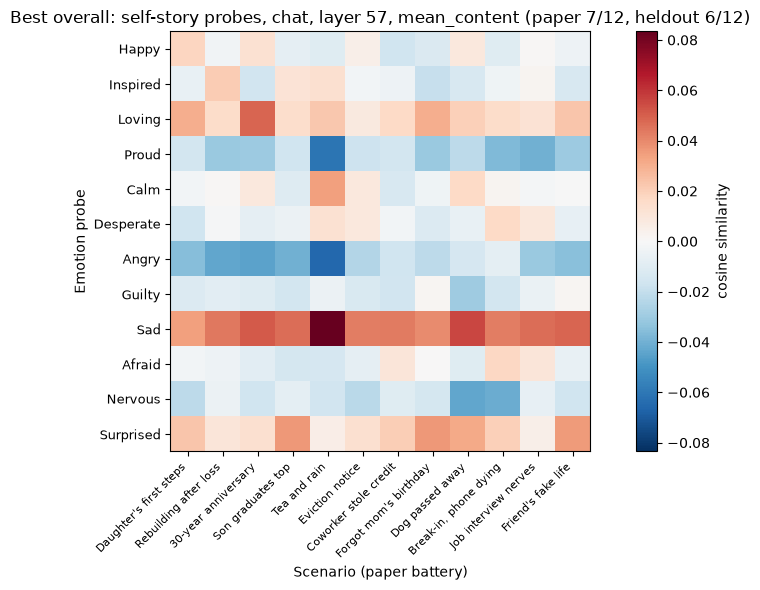

In [3]:
best = rows[0]
t_p, M = score(SETS[best[2]], best[3], "scenario", best[5], layers.index(best[4]))
scen_names = [prompts[i]["name"] for i in batteries["scenario"]]
fig, ax = plt.subplots(figsize=(9.5, 6))
vmax = np.abs(M).max()
im = ax.imshow(M, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax.set_xticks(range(12)); ax.set_xticklabels(scen_names, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(12)); ax.set_yticklabels([e.capitalize() for e in probe_order], fontsize=9)
ax.set_xlabel("Scenario (paper battery)"); ax.set_ylabel("Emotion probe")
plt.colorbar(im, label="cosine similarity")
ax.set_title(f"Best overall: {best[2]} probes, {best[3]}, layer {best[4]}, {best[5]} "
             f"(paper {best[0]}/12, heldout {best[1]}/12)")
plt.tight_layout(); plt.show()

## Reading

The registered-rule cell is the verdict; TREE.md (Q1.H2.E5) records it. If NONE passes here,
every methodological repair — instruct model, chat format, self-generated leak-free probe data,
position/layer sweep — has been tried under pre-registered rules, and the remaining
explanations are substantive: corpus scale (C2's noise ceiling, ~16 texts/emotion here vs the
paper's ~1,000) and genuine model difference from the paper's Claude models.